## DS-Workshop: Classification Studies

* Task : Improve Result Score above 0.99

### Hyperparameter Tuuning:

In machine learning, a hyperparameter is an external configuration variable set manually before training begins. It governs the learning process itself.

#### Dataset: breast_cancer

##### 1) Import liberies:

In [ ]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import stats
from scipy.stats import yeojohnson

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import f1_score, confusion_matrix,classification_report, accuracy_score, precision_score, recall_score

from warnings import filterwarnings  # For filter and hide warnings along run a program or script
filterwarnings('ignore')

##### 2) Load Data:

In [2]:
# Breast Cancer Dataset
cancer = datasets.load_breast_cancer(as_frame=True)
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

In [3]:
df = pd.concat([X, y], axis=1)

In [4]:
df.shape

(569, 31)

In [5]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [9]:
df.nunique()

mean radius                456
mean texture               479
mean perimeter             522
mean area                  539
mean smoothness            474
mean compactness           537
mean concavity             537
mean concave points        542
mean symmetry              432
mean fractal dimension     499
radius error               540
texture error              519
perimeter error            533
area error                 528
smoothness error           547
compactness error          541
concavity error            533
concave points error       507
symmetry error             498
fractal dimension error    545
worst radius               457
worst texture              511
worst perimeter            514
worst area                 544
worst smoothness           411
worst compactness          529
worst concavity            539
worst concave points       492
worst symmetry             500
worst fractal dimension    535
target                       2
dtype: int64

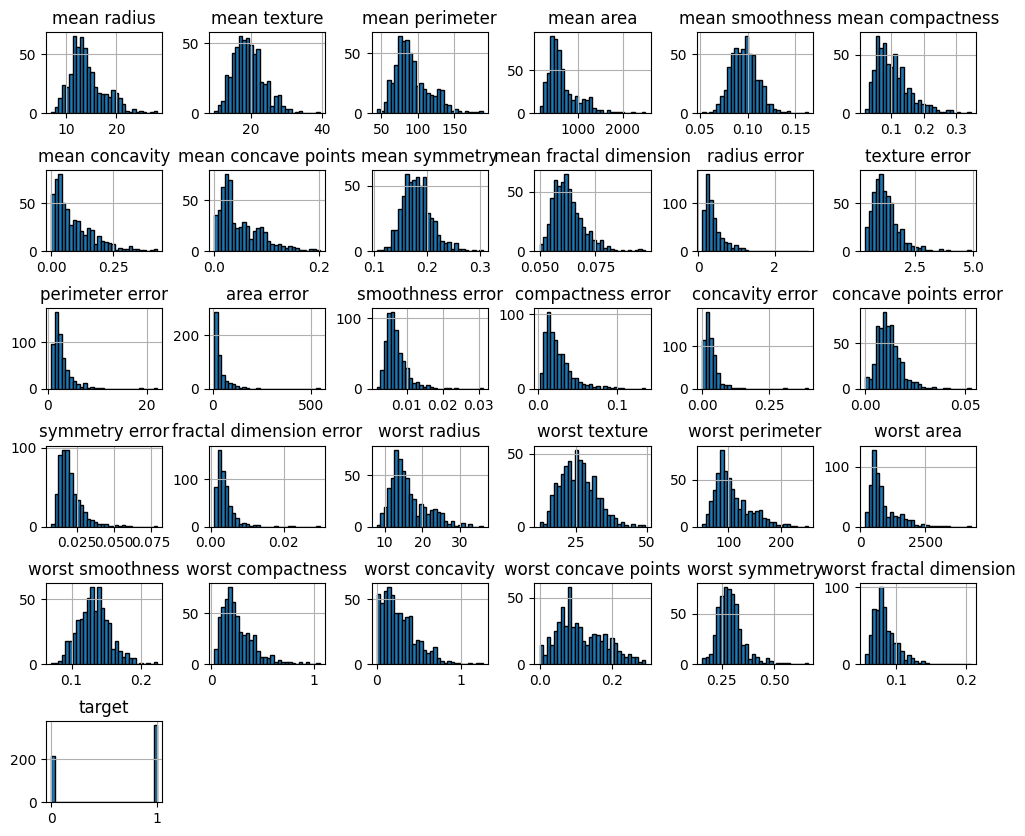

In [10]:
# Feature Visualization:
cancer.frame.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

##### 3) Preprocessing:

* 3-1) Null Handling:

In [11]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

* 3-2) Duplicates:

In [12]:
df.duplicated().sum()

np.int64(0)

* 3-3) Skewness:

In [13]:
print('Skewness before imputation: ')
print(df.skew())

Skewness before imputation: 
mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150237

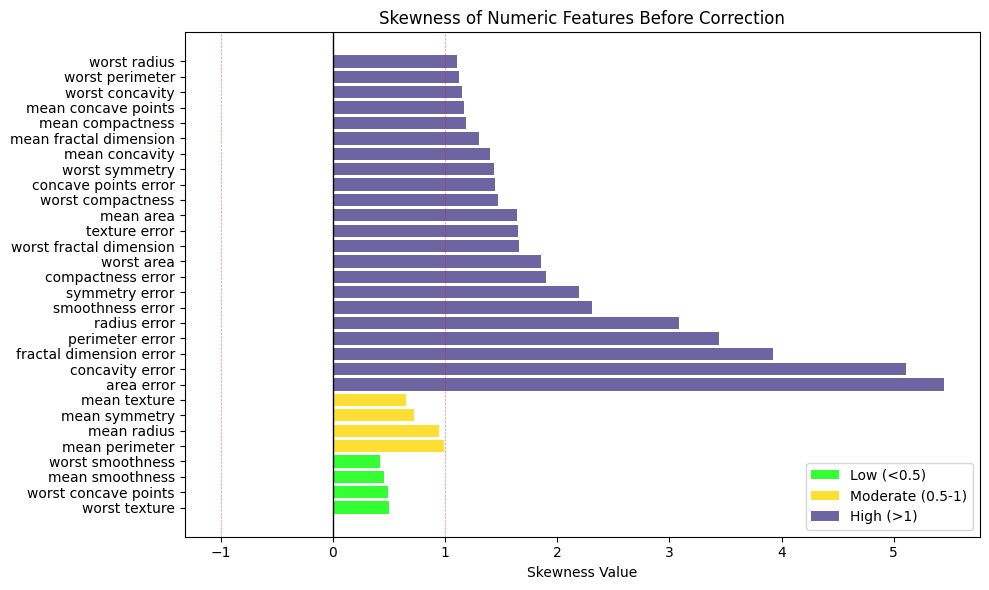


Skewness Summary:
                Feature  Skewness  Absolute_Skewness   Skewness_Level
             area error  5.447186           5.447186        High (>1)
        concavity error  5.110463           5.110463        High (>1)
fractal dimension error  3.923969           3.923969        High (>1)
        perimeter error  3.443615           3.443615        High (>1)
           radius error  3.088612           3.088612        High (>1)
       smoothness error  2.314450           2.314450        High (>1)
         symmetry error  2.195133           2.195133        High (>1)
      compactness error  1.902221           1.902221        High (>1)
             worst area  1.859373           1.859373        High (>1)
worst fractal dimension  1.662579           1.662579        High (>1)
          texture error  1.646444           1.646444        High (>1)
              mean area  1.645732           1.645732        High (>1)
      worst compactness  1.473555           1.473555        High (>1)
 

In [14]:
# Create a DataFrame with skewness information
skew_df = pd.DataFrame({
    'Feature': X.columns,
    'Skewness': [X[col].skew() for col in X.columns],
    'Absolute_Skewness': [abs(X[col].skew()) for col in X.columns]
}).sort_values('Absolute_Skewness', ascending=False)

# Categorize skewness levels
skew_df['Skewness_Level'] = pd.cut(skew_df['Absolute_Skewness'], 
                                    bins=[0, 0.5, 1, float('inf')],
                                    labels=['Low (<0.5)', 'Moderate (0.5-1)', 'High (>1)'])

# Create a styled table
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Low (<0.5)': 'lime', 'Moderate (0.5-1)': 'gold', 'High (>1)': 'darkslateblue'}
for level, group in skew_df.groupby('Skewness_Level'):
    ax.barh(group['Feature'], group['Skewness'], 
            color=colors[level], label=level, alpha=0.8)

ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(x=-1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Skewness Value')
ax.set_title('Skewness of Numeric Features Before Correction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Print the table
print("\nSkewness Summary:")
print(skew_df.to_string(index=False))

Handling 'mean area'  (skewness: 1.646)
Handling 'mean compactness'  (skewness: 1.190)
Handling 'mean concavity'  (skewness: 1.401)
Handling 'mean concave points'  (skewness: 1.171)
Handling 'mean fractal dimension'  (skewness: 1.304)
Handling 'radius error'  (skewness: 3.089)
Handling 'texture error'  (skewness: 1.646)
Handling 'perimeter error'  (skewness: 3.444)
Handling 'area error'  (skewness: 5.447)
Handling 'smoothness error'  (skewness: 2.314)
Handling 'compactness error'  (skewness: 1.902)
Handling 'concavity error'  (skewness: 5.110)
Handling 'concave points error'  (skewness: 1.445)
Handling 'symmetry error'  (skewness: 2.195)
Handling 'fractal dimension error'  (skewness: 3.924)
Handling 'worst radius'  (skewness: 1.103)
Handling 'worst perimeter'  (skewness: 1.128)
Handling 'worst area'  (skewness: 1.859)
Handling 'worst compactness'  (skewness: 1.474)
Handling 'worst concavity'  (skewness: 1.150)
Handling 'worst symmetry'  (skewness: 1.434)
Handling 'worst fractal dimensi

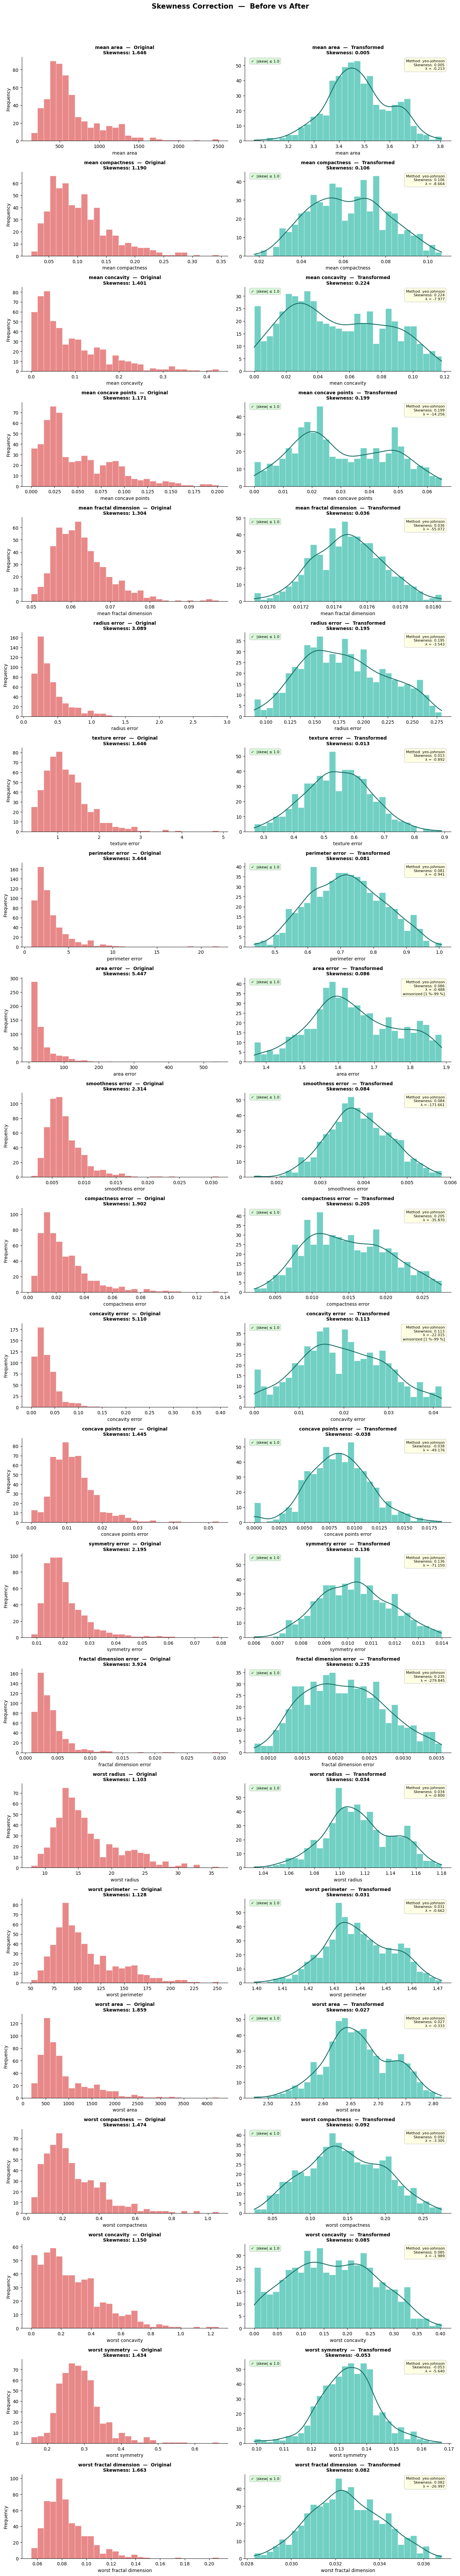

In [15]:

# ── Skewness handler ──────────────────────────────────────────────────────────

def simple_skewness_handler(df, threshold=1.0):
    """
    Apply skewness-reducing transforms to all numeric columns whose absolute
    skewness exceeds *threshold*.

    Returns
    -------
    normal_df   : pd.DataFrame  – copy of df with transformed columns
    normal_dict : dict          – per-column metadata for inverse-transform /
                                  audit trail
    """
    normal_df = df.copy()
    normal_dict = {}

    for col in normal_df.select_dtypes(include=[np.number]).columns:
        data = normal_df[col].dropna()
        skewness = data.skew()

        if abs(skewness) <= threshold:
            continue

        print(f"Handling '{col}'  (skewness: {skewness:.3f})")

        # ── Optional winsorisation for extreme skew ───────────────────────
        winsorized = False
        data_clipped = data.copy()
        if abs(skewness) > 5:
            q_low, q_high = data.quantile([0.01, 0.99])
            data_clipped = data.clip(q_low, q_high)
            winsorized = True

        # ── Try transformations in priority order ─────────────────────────
        transformed = None
        meta: dict = {"winsorized": winsorized, "shift": 0.0, "lambda": None}

        # 1. Yeo-Johnson (handles negatives natively)
        try:
            transformed, lam = yeojohnson(data_clipped)
            meta.update(method="yeo-johnson", lambda_=lam)
        except Exception as e:
            Warning.warn(f"  Yeo-Johnson failed for '{col}': {e}")

        # 2. Box-Cox (shift to positive domain if required)
        if transformed is None:
            try:
                shift = max(0.0, -data_clipped.min() + 1.0)
                transformed, lam = stats.boxcox(data_clipped + shift)
                meta.update(method="box-cox", lambda_=lam, shift=shift)
            except Exception as e:
                Warning.warn(f"  Box-Cox failed for '{col}': {e}")

        # 3. Simple closed-form fallback
        if transformed is None:
            try:
                if skewness > 0:
                    # log1p is safe for non-negative data; shift if needed
                    shift = max(0.0, -data_clipped.min())
                    transformed = np.log1p(data_clipped + shift)
                    meta.update(method="log1p", shift=shift)
                else:
                    # Reflect → sqrt → re-reflect for negative skew
                    shifted = data_clipped.max() + 1 - data_clipped
                    transformed = -np.sqrt(shifted)
                    meta.update(method="reflect-sqrt")
            except Exception as e:
                Warning.warn(f"  Fallback transform failed for '{col}': {e}")

        if transformed is None:
            Warning.warn(f"  All transforms failed for '{col}' — column unchanged.")
            continue

        normal_df.loc[data.index, col] = transformed
        normal_dict[col] = meta

    return normal_df, normal_dict


# ── Diagnostic plot ───────────────────────────────────────────────────────────

def plot_skewness_static(df_original, normalized_df, normal_dict,
                         numeric_cols=None, threshold=1.0):
    """
    Side-by-side histograms (before / after) for every column that was
    transformed.  A KDE overlay on the 'after' panel helps judge normality;
    a ✓/✗ badge shows whether the transform beat *threshold*.
    """
    if numeric_cols is None:
        numeric_cols = df_original.select_dtypes(include=[np.number]).columns

    transformed_cols = [c for c in numeric_cols if c in normal_dict]

    if not transformed_cols:
        print("No columns were transformed – nothing to plot.")
        return

    n_cols = len(transformed_cols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3.5 * n_cols))

    # Ensure axes is always 2-D
    if n_cols == 1:
        axes = axes.reshape(1, -1)

    HIST_KW  = dict(bins=30, alpha=0.72, edgecolor="white", linewidth=0.5)
    BBOX_KW  = dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                    edgecolor="#ccc", alpha=0.9)

    for i, col in enumerate(transformed_cols):
        orig_data  = df_original[col].dropna()
        norm_data  = normalized_df[col].dropna()
        orig_skew  = orig_data.skew()
        norm_skew  = norm_data.skew()

        # ── Left: original ────────────────────────────────────────────────
        ax_l = axes[i, 0]
        ax_l.hist(orig_data, color="#E05C5C", **HIST_KW)
        ax_l.set_title(f"{col}  —  Original\nSkewness: {orig_skew:.3f}",
                       fontsize=10, fontweight="bold")
        ax_l.set_ylabel("Frequency")
        ax_l.set_xlabel(col)
        ax_l.spines[["top", "right"]].set_visible(False)

        # ── Right: transformed ────────────────────────────────────────────
        ax_r = axes[i, 1]
        ax_r.hist(norm_data, color="#3BBFAD", **HIST_KW)

        # KDE overlay
        try:
            from scipy.stats import gaussian_kde
            kde_x = np.linspace(norm_data.min(), norm_data.max(), 300)
            kde_y = gaussian_kde(norm_data)(kde_x)
            # Scale KDE to histogram height
            bin_width = (norm_data.max() - norm_data.min()) / 30
            ax_r.plot(kde_x, kde_y * len(norm_data) * bin_width,
                      color="#1a6e66", linewidth=1.8, label="KDE")
        except Exception:
            pass  # KDE is cosmetic; never block the plot

        # ✓ / ✗ badge
        improved = abs(norm_skew) <= threshold
        badge    = f"{'✓' if improved else '✗'}  |skew| {'≤' if improved else '>'} {threshold}"
        badge_color = "#d4f7d4" if improved else "#ffd4d4"
        BBOX_KW_BADGE = {**BBOX_KW, "facecolor": badge_color}
        ax_r.text(0.03, 0.97, badge,
                  transform=ax_r.transAxes, fontsize=8,
                  va="top", ha="left",
                  bbox=BBOX_KW_BADGE)

        # Method annotation
        meta       = normal_dict[col]
        method     = meta.get("method", "unknown")
        lambda_val = meta.get("lambda_", meta.get("lambda"))   # support both keys
        info_lines = [f"Method: {method}",
                      f"Skewness: {norm_skew:.3f}"]
        if lambda_val is not None:          # ← fixed: catches λ = 0.0
            info_lines.append(f"λ = {lambda_val:.3f}")
        if meta.get("shift", 0):
            info_lines.append(f"shift = {meta['shift']:.3f}")
        if meta.get("winsorized"):
            info_lines.append("winsorized [1 %–99 %]")

        ax_r.text(0.97, 0.97, "\n".join(info_lines),
                  transform=ax_r.transAxes, fontsize=8,
                  va="top", ha="right", bbox=BBOX_KW)

        ax_r.set_title(f"{col}  —  Transformed\nSkewness: {norm_skew:.3f}",
                       fontsize=10, fontweight="bold")
        ax_r.set_xlabel(col)
        ax_r.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Skewness Correction  —  Before vs After",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
normal_df, normals = simple_skewness_handler(df, threshold=1.0)
plot_skewness_static(df, normal_df, normals)

* 3-4) Outliers Handling:

type of outliers:

1) Global Outliers (Point Anomalies): Individual data points that lie far from the rest.

2) Contextual Outliers: Outliers relative to a specific context or condition.

3) Collective Outliers: A group of related data points behaving anomalously together.

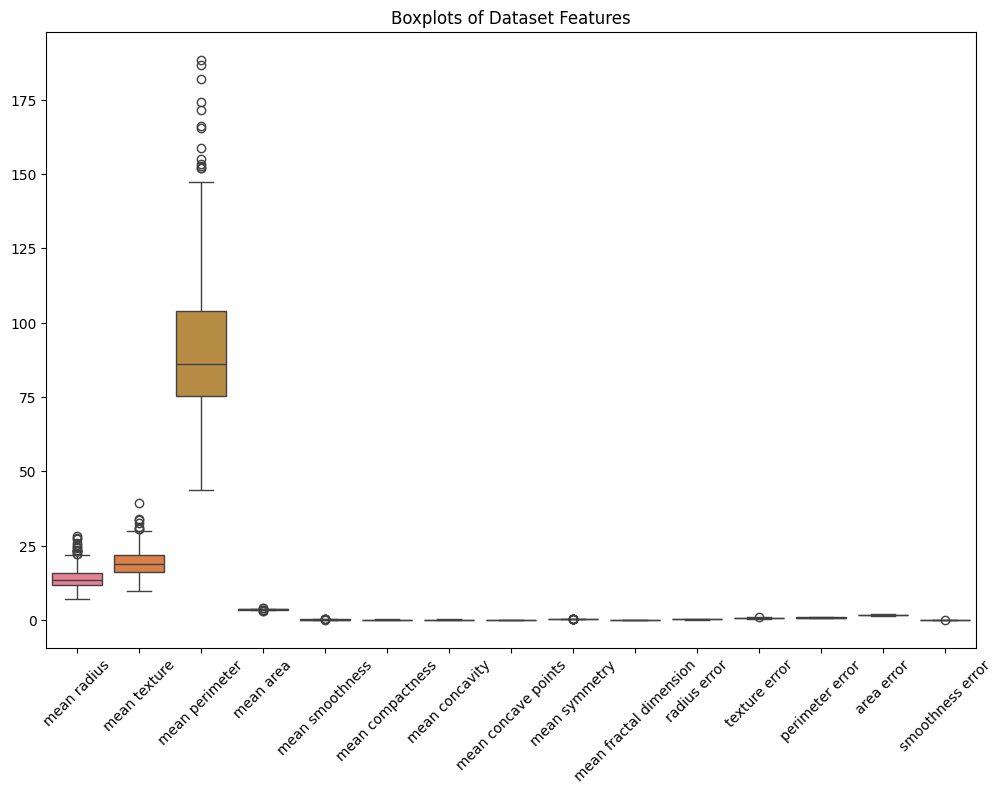

In [16]:
# Outlier detection columns 0-15:
data1 = normal_df.iloc[:,0:15]
plt.figure(figsize=(12, 8))
sns.boxplot(data=data1)
plt.xticks(rotation=45)
plt.title("Boxplots of Dataset Features")
plt.show()

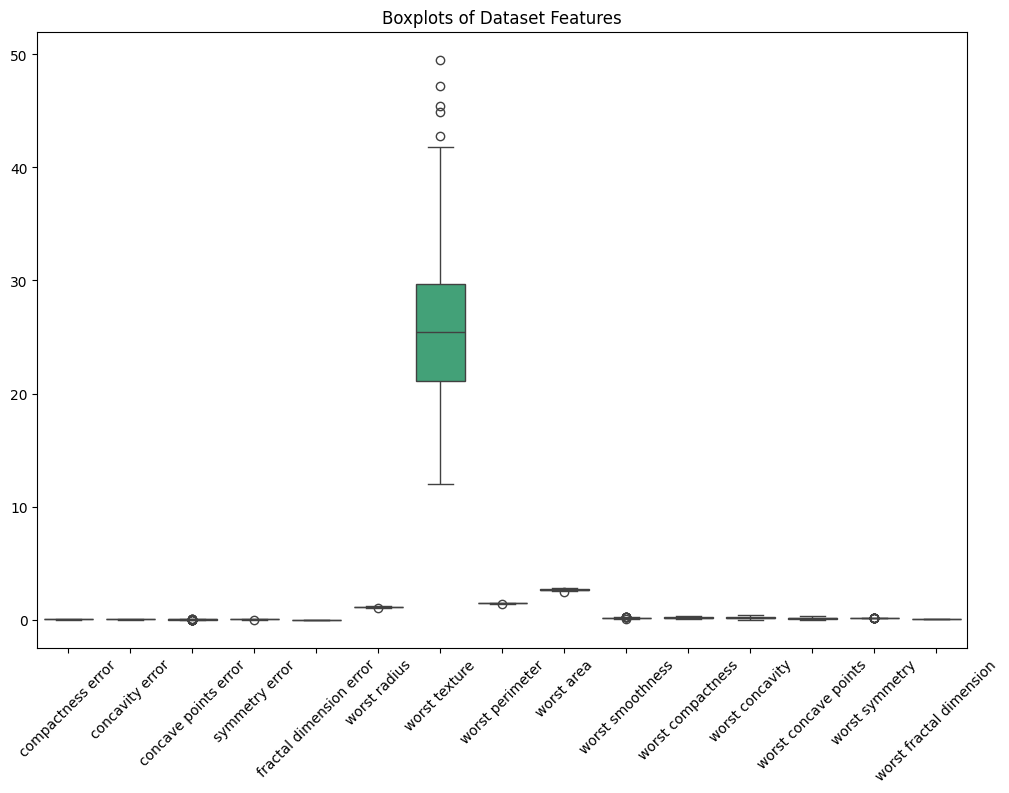

In [17]:
# Outlier detection columns 15-30:
data2 = normal_df.iloc[:,15:30]
plt.figure(figsize=(12, 8))
sns.boxplot(data=data2)
plt.xticks(rotation=45)
plt.title("Boxplots of Dataset Features")
plt.show()

* Methods:

* 3-4-1. Z-Score Method

he Z-Score method is a statistical technique that detects outliers based on how far a data point is from the mean, measured in terms of standard deviations. 

It assumes the data follows a normal distribution. A point with a very high or low Z-score (typically |Z| > 3) is flagged as an outlier because it lies in the extreme tails of the distribution.

In [18]:
from scipy import stats
z_scores = np.abs(stats.zscore(normal_df.select_dtypes(include=[np.number])))
outliers_z = np.where(z_scores > 3)

print("Outlier positions (row, col):")
out_val = (list(zip(outliers_z[0][:10], outliers_z[1][:10])))
for val in out_val:
    print(val)

Outlier positions (row, col):
(np.int64(3), np.int64(4))
(np.int64(3), np.int64(24))
(np.int64(3), np.int64(28))
(np.int64(25), np.int64(8))
(np.int64(38), np.int64(28))
(np.int64(60), np.int64(8))
(np.int64(78), np.int64(8))
(np.int64(82), np.int64(0))
(np.int64(82), np.int64(2))
(np.int64(101), np.int64(3))


* 3-4-2. IQR Method (Interquartile Range)

The IQR method is a robust statistical approach that identifies outliers by examining the spread of the middle 50% of the data. 

It calculates the Interquartile Range (IQR), which is the difference between the 75th percentile (Q3) and 25th percentile (Q1). 

Any value that falls below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR is considered an outlier.

In [19]:
data = normal_df
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
mean radius                14
mean texture                7
mean perimeter             13
mean area                   6
mean smoothness             6
mean compactness            0
mean concavity              0
mean concave points         0
mean symmetry              15
mean fractal dimension      0
radius error                0
texture error               1
perimeter error             0
area error                  0
smoothness error            1
compactness error           0
concavity error             0
concave points error       17
symmetry error              1
fractal dimension error     0
worst radius                1
worst texture               5
worst perimeter             1
worst area                  1
worst smoothness            7
worst compactness           0
worst concavity             0
worst concave points        0
worst symmetry             13
worst fractal dimension     0
target                      0
dtype: int64


* 3-4-3. Isolation Forest:

Isolation Forest is a model-based anomaly detection algorithm that isolates outliers instead of profiling normal data. It builds multiple random decision trees by repeatedly splitting the data.

Since outliers are few and different, they are easier to isolate and require fewer splits.

How it works:

- Randomly select features and split values.

- Construct isolation trees.

- Compute average path length for each point.

- Shorter path = more likely outlier.

Pros: Works well in high dimensions, efficient.

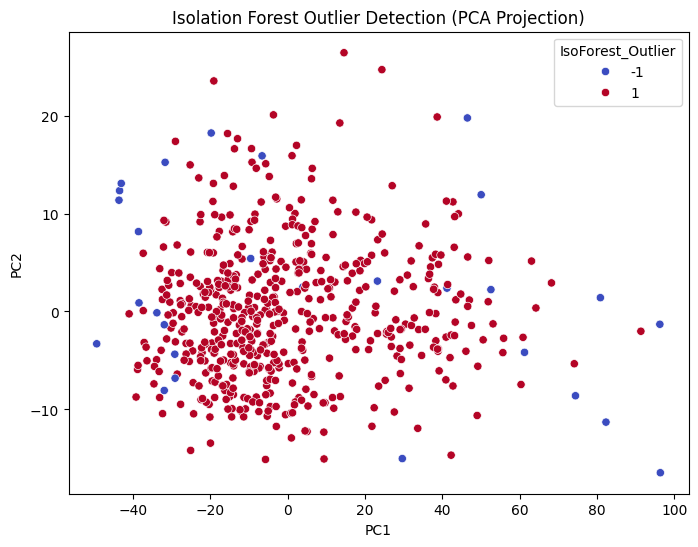

In [20]:
normal_df.columns = normal_df.columns.astype(str)

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

y_pred_iso = iso.fit_predict(normal_df)

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(normal_df)

# Create plotting dataframe
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["IsoForest_Outlier"] = y_pred_iso

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="IsoForest_Outlier",
    palette="coolwarm"
)

plt.title("Isolation Forest Outlier Detection (PCA Projection)")
plt.show()

In [21]:
outliers = normal_df[y_pred_iso == -1]
print(outliers.head())
print(f"Number of outliers: {len(outliers)}")

    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0         17.99         10.38          122.80   3.613777          0.11840   
3         11.42         20.38           77.58   3.372380          0.14250   
9         12.46         24.04           83.97   3.429603          0.11860   
12        19.17         24.80          132.40   3.639760          0.09740   
38        14.99         25.20           95.54   3.528370          0.09387   

    mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.101601        0.109906             0.060231         0.2419   
3           0.102178        0.103021             0.053293         0.2597   
9           0.097469        0.100890             0.048346         0.2030   
12          0.098228        0.097316             0.054664         0.2397   
38          0.040602        0.021592             0.023473         0.1565   

    mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0

* Keep clean data without outliers:

In [22]:
clean_df = normal_df[y_pred_iso == 1].copy()

* 3-5) Feature engineering:

Feature engineering is the process of using domain knowledge and statistical methods to transform raw data into informative, machine-readable inputs (features) for predictive models.

-The Core Processes:

- Feature Creation: Generating entirely new variables from existing data based on domain rules or patterns.

- Feature Transformation: Modifying existing data so it can be understood and processed more effectively by algorithms.

- Feature Extraction: Reducing the complexity of high-dimensional data (like text or images) into a smaller, more informative representation.

- Feature Selection: Identifying and keeping only the most predictive variables while removing irrelevant or noisy data. This prevents the model from "overfitting" or memorizing the training data.

** Here, since this dataset has 31 feature -> Doing feature selection

1) Filter methods: Based on statistical measures like correlation.

2) Wrapper methods: Select based on model performance.

3) Embedded methods: Feature selection integrated within model training.

* 3-5-1) Correlation Analyze:

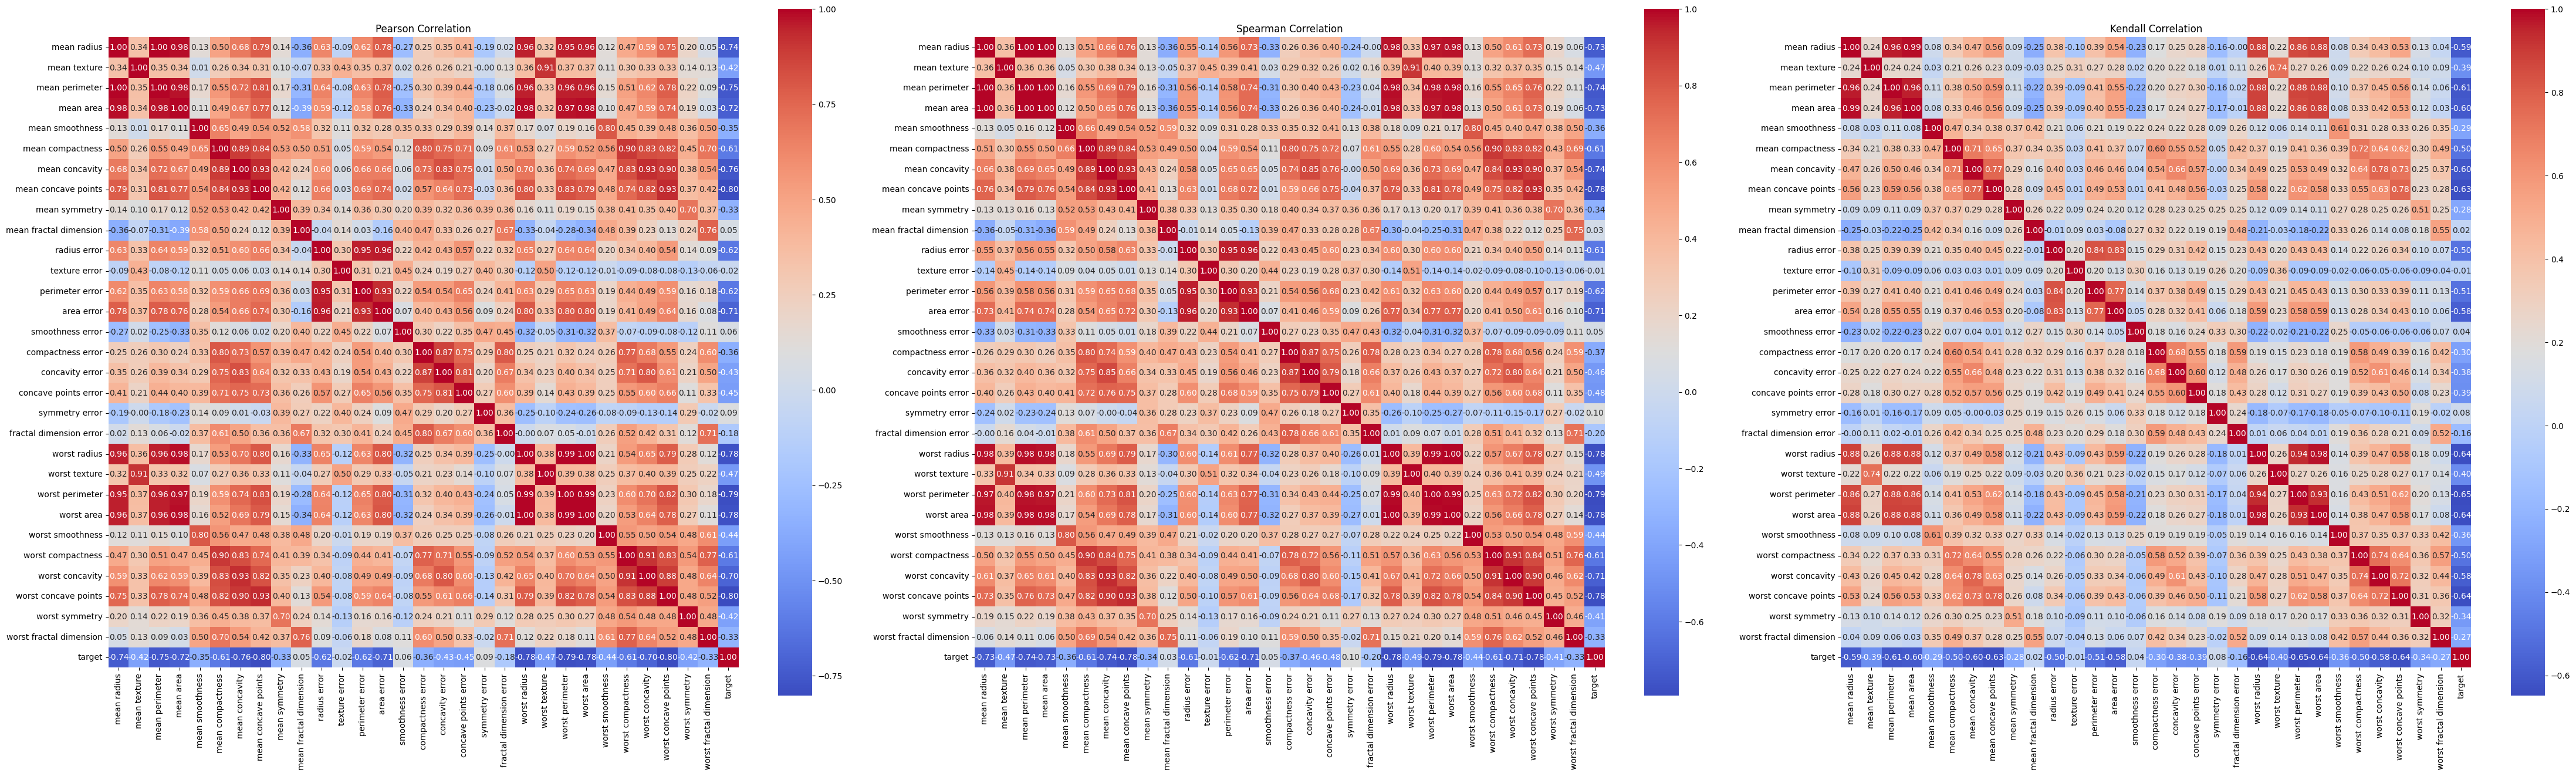

In [23]:
# 3-5-1.Compare Pearson, Spearman, and Kendall correlations
pearson_corr = clean_df.corr('pearson')
spearman_corr = clean_df.corr('spearman')
kendall_corr = clean_df.corr('kendall')

# Visualize differences
fig, axes = plt.subplots(1,3, figsize=(45, 15))
methods = ['Pearson', 'Spearman', 'Kendall']
corr_mats = [pearson_corr, spearman_corr, kendall_corr]

for ax, method, corr_mat in zip(axes, methods, corr_mats):
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, 
                square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(f'{method} Correlation')
plt.tight_layout()
plt.show()

In [24]:
# Identifying Highly Correlated Features (Multicollinearity)
# Find pairs of highly correlated features (e.g., > 0.8 or < -0.8)
threshold = 0.75
high_corr_pairs = []
feature_core = clean_df.corr('pearson')

for i in range(len(feature_core.columns)):
    for j in range(i):
        if abs(feature_core.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                feature_core.columns[i], 
                feature_core.columns[j], 
                feature_core.iloc[i, j]
            ))

# Display high correlations
high_corr_pairs.sort(reverse=True, key=lambda x: x[2])
print("Highly correlated feature pairs:")
for pair in high_corr_pairs:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")

Highly correlated feature pairs:
worst area & worst radius: 0.999
mean perimeter & mean radius: 0.998
worst perimeter & worst radius: 0.994
worst area & worst perimeter: 0.993
worst area & mean area: 0.980
mean area & mean radius: 0.980
worst radius & mean area: 0.980
mean area & mean perimeter: 0.977
worst perimeter & mean area: 0.974
area error & radius error: 0.961
worst radius & mean radius: 0.958
worst radius & mean perimeter: 0.957
worst area & mean radius: 0.957
worst area & mean perimeter: 0.956
worst perimeter & mean perimeter: 0.956
perimeter error & radius error: 0.954
worst perimeter & mean radius: 0.951
mean concave points & mean concavity: 0.935
worst concave points & mean concave points: 0.931
worst concavity & mean concavity: 0.929
area error & perimeter error: 0.926
worst texture & mean texture: 0.913
worst concavity & worst compactness: 0.911
worst concave points & mean concavity: 0.900
worst compactness & mean compactness: 0.899
mean concavity & mean compactness: 0.8

In [25]:
# High Correlation Count
from collections import Counter

feature_counts = Counter()

for f1, f2, corr in high_corr_pairs:
    feature_counts[f1] += 1
    feature_counts[f2] += 1

# Convert to DataFrame
corr_summary = pd.DataFrame(
    feature_counts.items(),
    columns=["Feature", "High_Correlation_Count"]
)

corr_summary = corr_summary.sort_values(
    by="High_Correlation_Count",
    ascending=False
)

print(corr_summary)

                    Feature  High_Correlation_Count
9       mean concave points                      11
11     worst concave points                      10
0                worst area                       9
2            mean perimeter                       9
1              worst radius                       9
4           worst perimeter                       9
6                area error                       8
10           mean concavity                       7
25                   target                       7
5                 mean area                       7
3               mean radius                       7
12          worst concavity                       6
15        worst compactness                       6
16         mean compactness                       6
18        compactness error                       5
17          concavity error                       4
23  worst fractal dimension                       2
19     concave points error                       2
8           

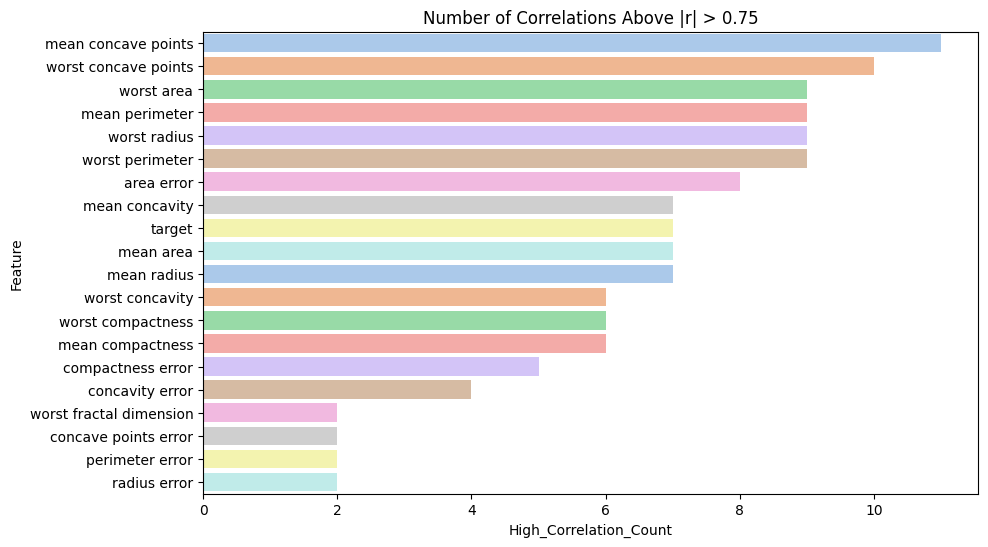

In [26]:
plt.figure(figsize=(10, 6))
palet = sns.color_palette("pastel")
sns.barplot(
    data=corr_summary.head(20),
    x="High_Correlation_Count",
    y="Feature",
    palette=palet
)

plt.title(
    f"Number of Correlations Above |r| > {threshold}"
)

plt.show()

In [27]:
# Best features based Correlation:
data=corr_summary.head(26)
data

,Feature,High_Correlation_Count
9,mean concave points,11
11,worst concave points,10
0,worst area,9
2,mean perimeter,9
1,worst radius,9
4,worst perimeter,9
6,area error,8
10,mean concavity,7
25,target,7
5,mean area,7


In [28]:
normal_df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

FEATURE SELECTION RESULTS
Original features: 30
Selected features: 26
Removed features: 4

Top 10 features:
             Feature  Correlation
worst concave points     0.793566
     worst perimeter     0.782914
 mean concave points     0.776614
        worst radius     0.776454
      mean perimeter     0.742636
          worst area     0.733825
         mean radius     0.730029
           mean area     0.708984
      mean concavity     0.696360
     worst concavity     0.659610


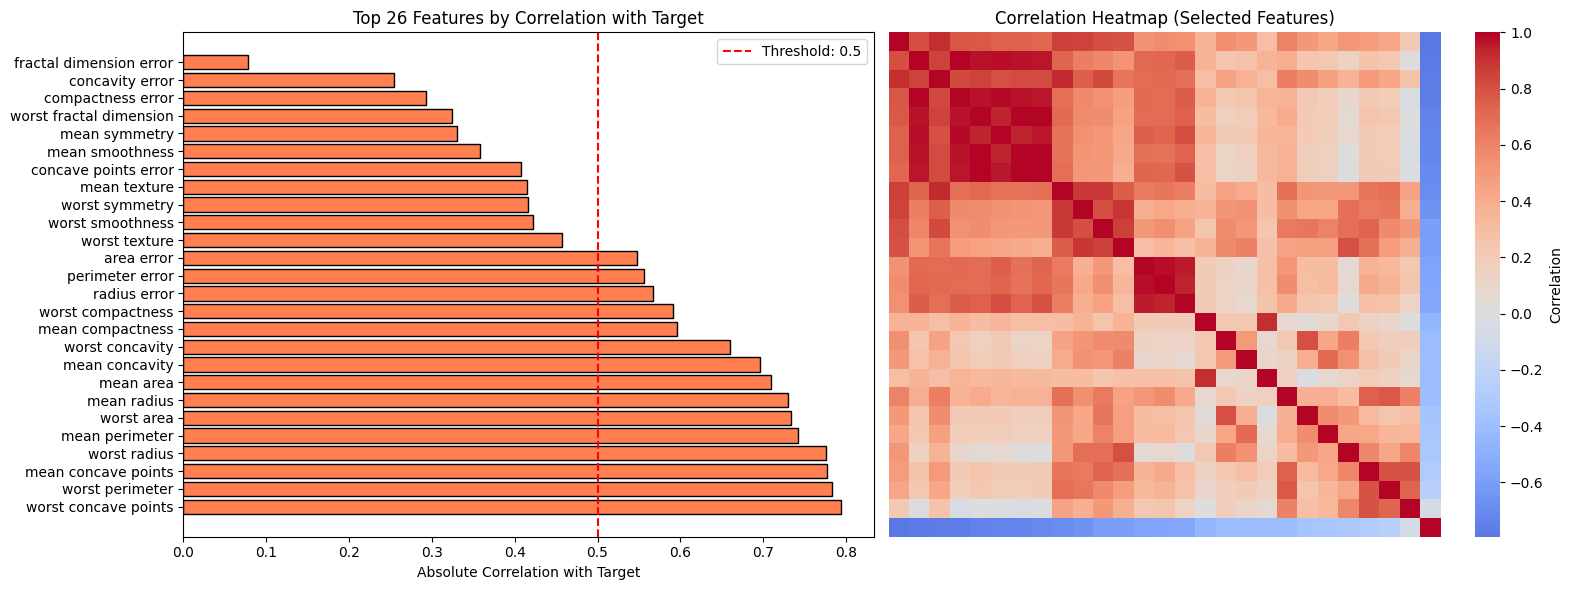

In [29]:

normal_df = df.copy()  

# Calculate correlations
corr_matrix = normal_df.corr()
corr_with_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)

# Create correlation summary
corr_summary = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Correlation': corr_with_target.values
})

# Get top features (e.g., top 26)
top_26 = corr_summary.head(26)
selected_features = top_26['Feature'].tolist()

# Create new dataframe
new_df = normal_df[selected_features + ['target']]

print("="*60)
print("FEATURE SELECTION RESULTS")
print("="*60)
print(f"Original features: {len(df.columns) - 1}")
print(f"Selected features: {len(selected_features)}")
print(f"Removed features: {len(df.columns) - 1 - len(selected_features)}")
print(f"\nTop 10 features:")
print(top_26.head(10).to_string(index=False))

# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top feature correlations
axes[0].barh(top_26['Feature'], top_26['Correlation'], color='coral', edgecolor='black')
axes[0].set_xlabel('Absolute Correlation with Target')
axes[0].set_title('Top 26 Features by Correlation with Target')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold: 0.5')
axes[0].legend()

# Plot 2: Heatmap of selected features
selected_corr = normal_df[selected_features + ['target']].corr()
sns.heatmap(selected_corr, cmap='coolwarm', center=0, ax=axes[1], 
            cbar_kws={'label': 'Correlation'}, xticklabels=False, yticklabels=False)
axes[1].set_title('Correlation Heatmap (Selected Features)')

plt.tight_layout()
plt.show()

* 3-5-2: Feature Selection Methods: 

- 1. ANOVA F-test

- 2. Mutual Information

- 3. Random Forest Feature Importance

- 4. Recursive Feature Elimination

In [30]:

X = normal_df.drop('target', axis=1)
y = normal_df['target']

# Method 1: ANOVA F-test (for linear relationships)
def select_kbest_anova(X, y, k=26):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_new = selector.fit_transform(X, y)
    selected = X.columns[selector.get_support()].tolist()
    return selected, selector

# Method 2: Mutual Information (captures non-linear)
def select_mutual_info(X, y, k=26):
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_new = selector.fit_transform(X, y)
    selected = X.columns[selector.get_support()].tolist()
    return selected, selector

# Method 3: Random Forest Feature Importance
def select_rf_importance(X, y, k=26):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    selected = importances.nlargest(k).index.tolist()
    return selected, importances

# Method 4: Recursive Feature Elimination
def select_rfe(X, y, k=26):
    estimator = RandomForestClassifier(n_estimators=100, random_state=42)
    selector = RFE(estimator, n_features_to_select=k)
    selector.fit(X, y)
    selected = X.columns[selector.support_].tolist()
    return selected, selector

# Compare methods
print("="*60)
print("FEATURE SELECTION METHODS COMPARISON")
print("="*60)

for name, func in [('Correlation', None), ('ANOVA F-test', select_kbest_anova), 
                    ('Mutual Info', select_mutual_info), ('RF Importance', select_rf_importance)]:
    if name == 'Correlation':
        features = selected_features
    else:
        features, _ = func(X, y, k=26)
    
    print(f"\n{name}: {len(features)} features selected")
    print(f"Top 5: {features[:5]}")

# Create the BEST new_df using Random Forest (usually most robust)
best_features, importances = select_rf_importance(X, y, k=26)
best_df = normal_df[best_features + ['target']]

print(f"\n✅ Best DataFrame created: {best_df.shape}")


FEATURE SELECTION METHODS COMPARISON

Correlation: 26 features selected
Top 5: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter']

ANOVA F-test: 26 features selected
Top 5: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

Mutual Info: 26 features selected
Top 5: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

RF Importance: 26 features selected
Top 5: ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'worst perimeter']

✅ Best DataFrame created: (569, 27)


* 3-5-3: Validate with Cross-Validation

In [31]:
# Compare model performance with different feature sets
def compare_feature_sets(X_full, y, feature_sets, model=None):
    if model is None:
        model = RandomForestClassifier(random_state=42)
    
    results = {}
    for name, features in feature_sets.items():
        X_subset = X_full[features]
        scores = cross_val_score(model, X_subset, y, cv=5, scoring='accuracy')
        results[name] = {
            'mean_score': scores.mean(),
            'std_score': scores.std(),
            'n_features': len(features)
        }
    return pd.DataFrame(results).T

# Define feature sets to compare
feature_sets = {
    'Top 10 Corr': selected_features[:10],
    'Top 20 Corr': selected_features[:20],
    'Top 26 Corr': selected_features[:26],
    'All Features': X.columns.tolist(),
    'RF Top 26': best_features
}

# Compare with Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
results = compare_feature_sets(X, y, feature_sets, model=rf)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON (Random Forest, 5-fold CV)")
print("="*60)
print(results.to_string())

# Find best
best = results['mean_score'].idxmax()
print(f"\n✅ Best feature set: {best}")
print(f"   Accuracy: {results.loc[best, 'mean_score']:.4f} (+/- {results.loc[best, 'std_score']:.4f})")


MODEL PERFORMANCE COMPARISON (Random Forest, 5-fold CV)
              mean_score  std_score  n_features
Top 10 Corr     0.945552   0.030550        10.0
Top 20 Corr     0.964866   0.020739        20.0
Top 26 Corr     0.961341   0.020449        26.0
All Features    0.956094   0.022839        30.0
RF Top 26       0.959603   0.022575        26.0

✅ Best feature set: Top 20 Corr
   Accuracy: 0.9649 (+/- 0.0207)


In [32]:
best_df

,worst area,worst concave points,mean concave points,worst radius,worst perimeter,mean perimeter,mean concavity,mean area,worst concavity,mean radius,...,perimeter error,worst symmetry,mean smoothness,fractal dimension error,concavity error,compactness error,smoothness error,worst fractal dimension,concave points error,target
0,2019.0,0.2654,0.14710,25.380,184.60,122.80,0.30010,1001.0,0.7119,17.99,...,8.589,0.4601,0.11840,0.006193,0.05373,0.04904,0.006399,0.11890,0.01587,0
1,1956.0,0.1860,0.07017,24.990,158.80,132.90,0.08690,1326.0,0.2416,20.57,...,3.398,0.2750,0.08474,0.003532,0.01860,0.01308,0.005225,0.08902,0.01340,0
2,1709.0,0.2430,0.12790,23.570,152.50,130.00,0.19740,1203.0,0.4504,19.69,...,4.585,0.3613,0.10960,0.004571,0.03832,0.04006,0.006150,0.08758,0.02058,0
3,567.7,0.2575,0.10520,14.910,98.87,77.58,0.24140,386.1,0.6869,11.42,...,3.445,0.6638,0.14250,0.009208,0.05661,0.07458,0.009110,0.17300,0.01867,0
4,1575.0,0.1625,0.10430,22.540,152.20,135.10,0.19800,1297.0,0.4000,20.29,...,5.438,0.2364,0.10030,0.005115,0.05688,0.02461,0.011490,0.07678,0.01885,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2027.0,0.2216,0.13890,25.450,166.10,142.00,0.24390,1479.0,0.4107,21.56,...,7.673,0.2060,0.11100,0.004239,0.05198,0.02891,0.010300,0.07115,0.02454,0
565,1731.0,0.1628,0.09791,23.690,155.00,131.20,0.14400,1261.0,0.3215,20.13,...,5.203,0.2572,0.09780,0.002498,0.03950,0.02423,0.005769,0.06637,0.01678,0
566,1124.0,0.1418,0.05302,18.980,126.70,108.30,0.09251,858.1,0.3403,16.60,...,3.425,0.2218,0.08455,0.003892,0.04730,0.03731,0.005903,0.07820,0.01557,0
567,1821.0,0.2650,0.15200,25.740,184.60,140.10,0.35140,1265.0,0.9387,20.60,...,5.772,0.4087,0.11780,0.006185,0.07117,0.06158,0.006522,0.12400,0.01664,0


##### 4) Split the data -> original_df & best_df

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Prepare optimized data
X_best = best_df.drop('target', axis=1)
y_best = best_df['target']
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
        X_best, y_best, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_best
    )

##### 5) Standardize the features:

In [34]:
# SVM & Naive Bayes
scaler = StandardScaler()
# original_df
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# best_df
X_train_best_scaled = scaler.fit_transform(X_train_best)
X_test_best_scaled = scaler.transform(X_test_best)


##### 6) Models:

* 6-1) Support Vector Mechine (SVM)

In [35]:
print(f'Evaluating SVM : ')
#kernels_best= 'rbf', 
svm_model = SVC( # 1: 0.9861
    probability=True,
    kernel='rbf',
    random_state=42,
)
# original_df
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# best_df
svm_model.fit(X_train_best_scaled,y_train_best)
y_pred_best_svm = svm_model.predict(X_test_best_scaled)

Evaluating SVM : 


* 6-1) Reports:

SVM F1-Score original_df : 0.9861
SVM F1-Score best_df : 0.9861


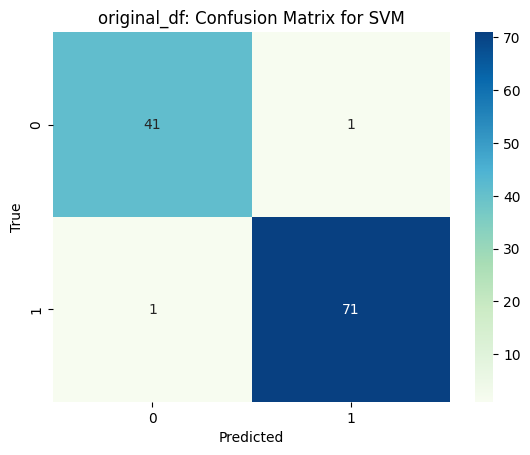

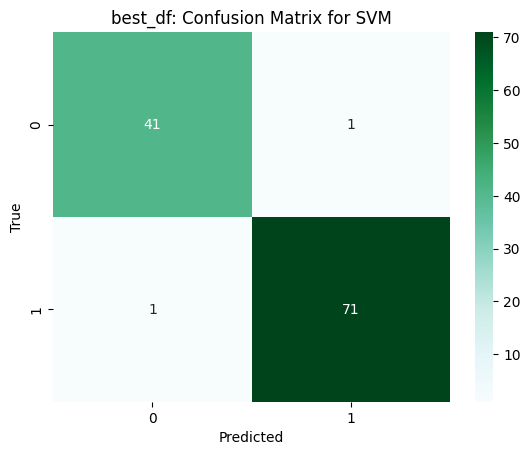

original_df -> SVM Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

------------------------------------------------------------
best_df -> SVM Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [36]:
# Calculate F1-Score original_df:
f1_svm = f1_score(y_test, y_pred_svm)
print(f'SVM F1-Score original_df : {f1_svm:.4f}')

# Calculate F1-Score best_df:
f1_best_svm = f1_score(y_test_best, y_pred_best_svm)
print(f'SVM F1-Score best_df : {f1_best_svm:.4f}')

# Confusion matrix original_df:
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion matrix best_df:
cm_best_svm = confusion_matrix(y_test_best, y_pred_best_svm)
sns.heatmap(
    cm_best_svm,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
print(f'original_df -> SVM Classification Report:\n', classification_report(y_test, y_pred_svm))
print('-'*60)
print(f'best_df -> SVM Classification Report:\n', classification_report(y_test_best, y_pred_best_svm))

* 6-2) Gaussian Naive Bayes:

In [47]:
print('\nEvaluating Naive Bayes: ')
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

# best_df
nb_model.fit(X_train_best_scaled, y_train_best)
y_pred_best_nb = nb_model.predict(X_test_best_scaled)


Evaluating Naive Bayes: 


* 6-2) Reports:

 Naive Bayes F1-Score original_df : 0.9444
 Naive Bayes F1-Score best_df : 0.9517


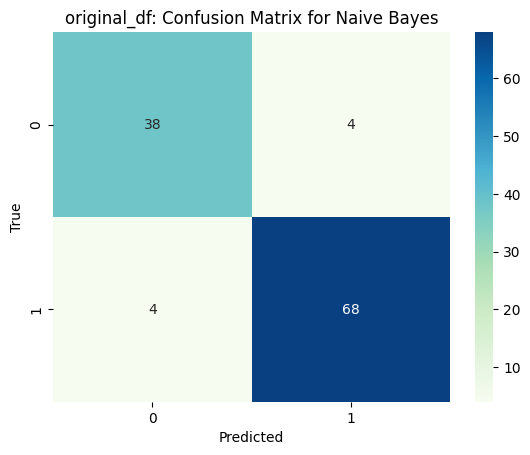

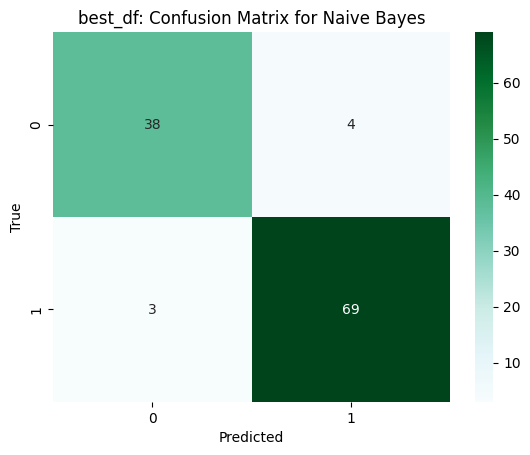

original_df -> Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

------------------------------------------------------------
best_df -> Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [48]:
# Calculate F1-Score original_df:
f1_nb = f1_score(y_test, y_pred_nb)
print(f' Naive Bayes F1-Score original_df : {f1_nb:.4f}')
# Calculate F1-Score original_df:
f1_best_nb = f1_score(y_test_best, y_pred_best_nb)
print(f' Naive Bayes F1-Score best_df : {f1_best_nb:.4f}')


# Confusion Matrix original df:
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix best_df:
cm_best_nb = confusion_matrix(y_test_best, y_pred_best_nb)
sns.heatmap(
    cm_best_nb,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(f'original_df -> Naive Bayes Classification Report:\n', classification_report(y_test, y_pred_nb))
print('-'*60)
print(f'best_df -> Naive Bayes Classification Report:\n', classification_report(y_test_best, y_pred_best_nb))

* 6-3) Random Forest

In [38]:
print('\nEvaluating Random Forest: ')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# best_df:
rf_model.fit(X_train_best, y_train_best)
y_pred_best_rf = rf_model.predict(X_test_best)


Evaluating Random Forest: 


* 6-3) Reports:

Random Forest F1-Score original_df: 0.9655
Random Forest F1-Score best_df: 0.9583


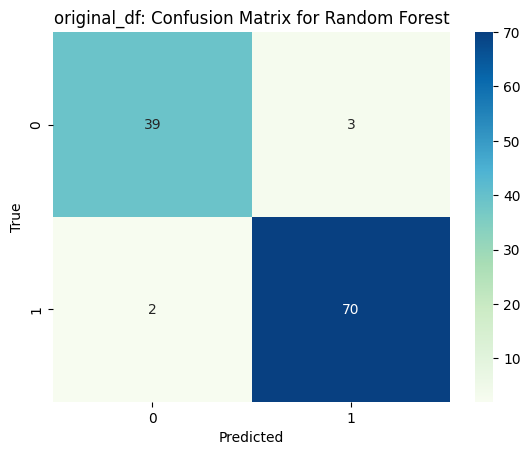

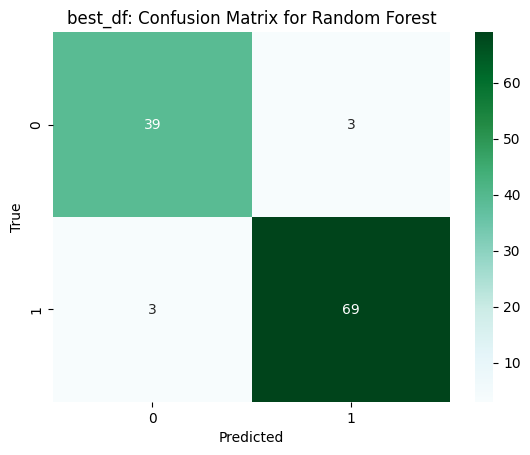

original_df -> Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------------------------------------
best_df -> Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [39]:
# Calculate F1-Score original_df:
f1_rf = f1_score(y_test, y_pred_rf)
print(f'Random Forest F1-Score original_df: {f1_rf:.4f}')

# Calculate F1-Score best_df:
f1_best_rf = f1_score(y_test_best, y_pred_best_rf)
print(f'Random Forest F1-Score best_df: {f1_best_rf:.4f}')

# Confusion Matrix original_df:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix best_df:
cm_best_rf = confusion_matrix(y_test_best, y_pred_best_rf)
sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(f'original_df -> Random Forest Classification Report:\n', classification_report(y_test, y_pred_rf))
print('-'*60)
print(f'best_df -> Random Forest Classification Report:\n', classification_report(y_test_best, y_pred_best_rf))

* 6-4) CatBoost:

In [40]:
print('\nEvaluating CatBoost: ')
catboost_model = CatBoostClassifier(verbose=0 ,random_state=42)

catboost_model.fit(X_train, y_train)
y_pred_catboost = catboost_model.predict(X_test)

# best_df:
catboost_model.fit(X_train_best, y_train_best)
y_pred_best_catboost = catboost_model.predict(X_test_best)


Evaluating CatBoost: 


* 6-4) Reports:

 CatBoost F1-Score original_df : 0.9660
 CatBoost F1-Score best_df : 0.9660


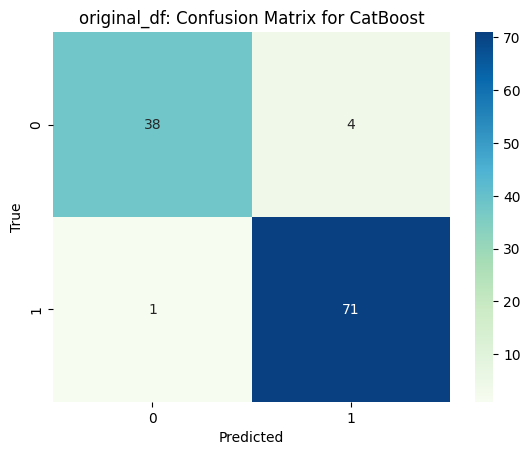

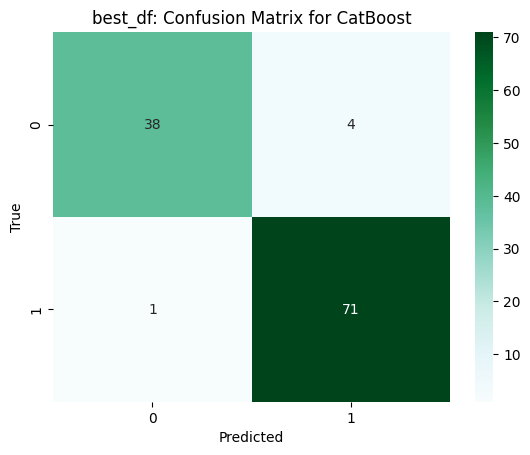

original_df -> CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------------------------------------
best_df -> CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [41]:
# Calculate F1-Score original_df:
f1_catboost = f1_score(y_test, y_pred_catboost)
print(f' CatBoost F1-Score original_df : {f1_catboost:.4f}')

# Calculate F1-Score best_df:
f1_best_catboost = f1_score(y_test_best, y_pred_best_catboost)
print(f' CatBoost F1-Score best_df : {f1_best_catboost:.4f}')

# Confusion Matrix original_df:
cm_catboost = confusion_matrix(y_test, y_pred_catboost)
sns.heatmap(
    cm_catboost,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for CatBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix best_df:
cm_best_catboost = confusion_matrix(y_test_best, y_pred_best_catboost)
sns.heatmap(
    cm_best_catboost,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for CatBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(f'original_df -> CatBoost Classification Report:\n', classification_report(y_test, y_pred_catboost))
print('-'*60)
print(f'best_df -> CatBoost Classification Report:\n', classification_report(y_test_best, y_pred_best_catboost))

* 6-5) LightGBM:

In [42]:
print('\nEvaluating LightGBM: ')
lgbm_model = LGBMClassifier(verbose=-1 ,random_state=42) # verbose = -1 -> no print any warnings

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

# best_df:
lgbm_model.fit(X_train_best, y_train_best)
y_pred_best_lgbm = lgbm_model.predict(X_test_best)


Evaluating LightGBM: 


* 6-5) Reports:

 LightGBM F1-Score original_df: 0.9726
 LightGBM F1-Score best_df: 0.9726


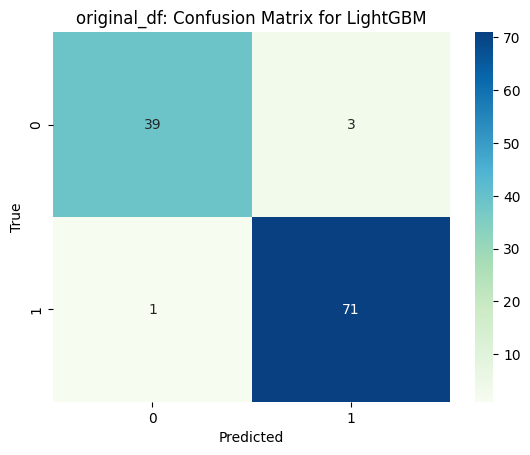

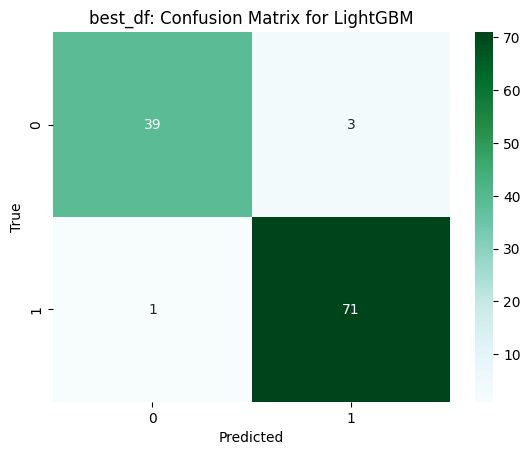

original_df -> LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

------------------------------------------------------------
best_df -> LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [49]:
# Calculate F1-Score original_df:
f1_lgbm = f1_score(y_test, y_pred_lgbm)
print(f' LightGBM F1-Score original_df: {f1_lgbm:.4f}')

# Calculate F1-Score best_df:
f1_best_lgbm = f1_score(y_test_best, y_pred_best_lgbm)
print(f' LightGBM F1-Score best_df: {f1_best_lgbm:.4f}')


# Confusion Matrix original_df:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for LightGBM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix best_df:
cm_best_lgbm = confusion_matrix(y_test_best, y_pred_best_lgbm)
sns.heatmap(
    cm_best_lgbm,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for LightGBM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(f'original_df -> LightGBM Classification Report:\n', classification_report(y_test, y_pred_lgbm))
print('-'*60)
print(f'best_df -> LightGBM Classification Report:\n', classification_report(y_test_best, y_pred_best_lgbm))

* 6-6) XGBoost:

In [44]:
print('\nEvaluating XGBoost: ')
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    )

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# best_df:
xgb_model.fit(X_train_best, y_train_best)
y_pred_best_xgb = xgb_model.predict(X_test_best)


Evaluating XGBoost: 


* 6-6) Reports:

 XGBoost F1-Score original_df: 0.9660
 XGBoost F1-Score best_df: 0.9730


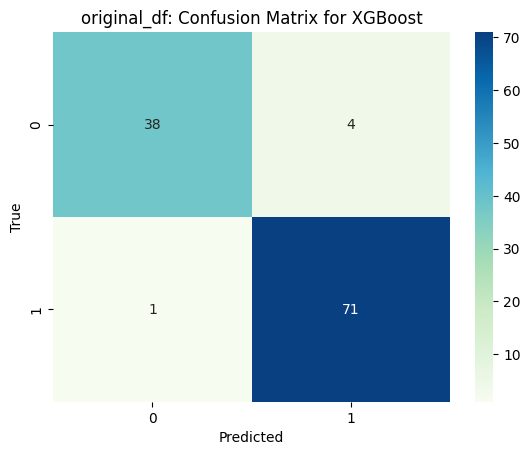

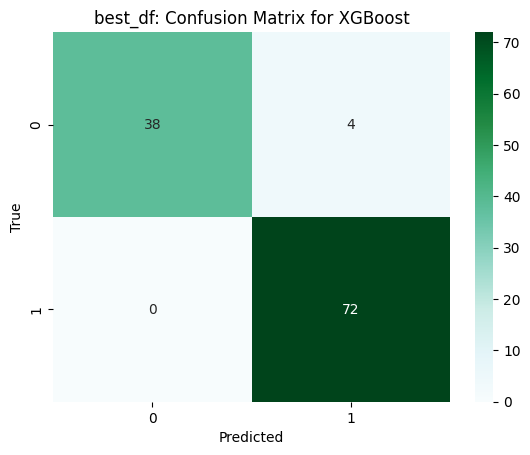

original_df -> XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

------------------------------------------------------------
best_df -> XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        42
           1       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [45]:
# Calculate F1-Score original_df:
f1_xgb = f1_score(y_test, y_pred_xgb)
print(f' XGBoost F1-Score original_df: {f1_xgb:.4f}')

# Calculate F1-Score best_df:
f1_best_xgb = f1_score(y_test_best, y_pred_best_xgb)
print(f' XGBoost F1-Score best_df: {f1_best_xgb:.4f}')

# Confusion Matrix original_df:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='GnBu',
)
plt.title('original_df: Confusion Matrix for XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix best_df:
cm_best_xgb = confusion_matrix(y_test_best, y_pred_best_xgb)
sns.heatmap(
    cm_best_xgb,
    annot=True,
    fmt='d',
    cmap='BuGn',
)
plt.title('best_df: Confusion Matrix for XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(f'original_df -> XGBoost Classification Report:\n', classification_report(y_test, y_pred_xgb))
print('-'*60)
print(f'best_df -> XGBoost Classification Report:\n', classification_report(y_test_best, y_pred_best_xgb))

#### Summary of F1-Score for comparison:

In [50]:
print('\nModel F1-Score : ')
print(f'SVM                   :{f1_svm:.4f}')
print(f'SVM_Best_df           :{f1_best_svm:.4f}')
print(f'Naive Bayes           :{f1_nb:.4f}')
print(f'Naive Bayes_Best_df   :{f1_best_nb:.4f}')
print(f'Random Forest         :{f1_rf:.4f}')
print(f'Random Forest_Best_df :{f1_best_rf:.4f}')
print(f'CatBoost              :{f1_catboost:.4f}')
print(f'CatBoost_Best_df      :{f1_best_catboost:.4f}')
print(f'LightGBM              :{f1_lgbm:.4f}')
print(f'LightGBM_Best_df      :{f1_best_lgbm:.4f}')
print(f'XGBoost               :{f1_xgb:.4f}')
print(f'XGBoost_Best_df       :{f1_best_xgb:.4f}')

# Model Score Selection on F1-Score:
best_model_score = max(
    [f1_svm, f1_best_svm, f1_nb, f1_best_nb, f1_rf, f1_best_rf, f1_catboost, f1_best_catboost, f1_lgbm, f1_best_lgbm, f1_xgb, f1_best_xgb]
    )
     

# Model Selection Based on F1-Score:
best_model_name = max(
    [('SVM', f1_svm),
     ('SVM_Best_df', f1_best_svm),
     ('Naive Bayes', f1_nb),
     ('Naive Bayes_Best_df', f1_best_nb),
     ('Random Forest', f1_rf),
     ('Random Forest_Best_df', f1_best_rf),
     ('CatBoost', f1_catboost),
     ('CatBoost_Best_df', f1_best_catboost),
     ('LightGBM', f1_lgbm),
     ('LightGBM_Best_df', f1_best_lgbm),
     ('XGBoost', f1_xgb),
     ('XGBoost_Best_df', f1_best_xgb)],
     key=lambda x: x[1],
)[0]
print(f'\nThe best model based F1-Score is: {best_model_name} with score {best_model_score:.4f}')


Model F1-Score : 
SVM                   :0.9861
SVM_Best_df           :0.9861
Naive Bayes           :0.9444
Naive Bayes_Best_df   :0.9517
Random Forest         :0.9655
Random Forest_Best_df :0.9583
CatBoost              :0.9660
CatBoost_Best_df      :0.9660
LightGBM              :0.9726
LightGBM_Best_df      :0.9726
XGBoost               :0.9660
XGBoost_Best_df       :0.9730

The best model based F1-Score is: SVM with score 0.9861


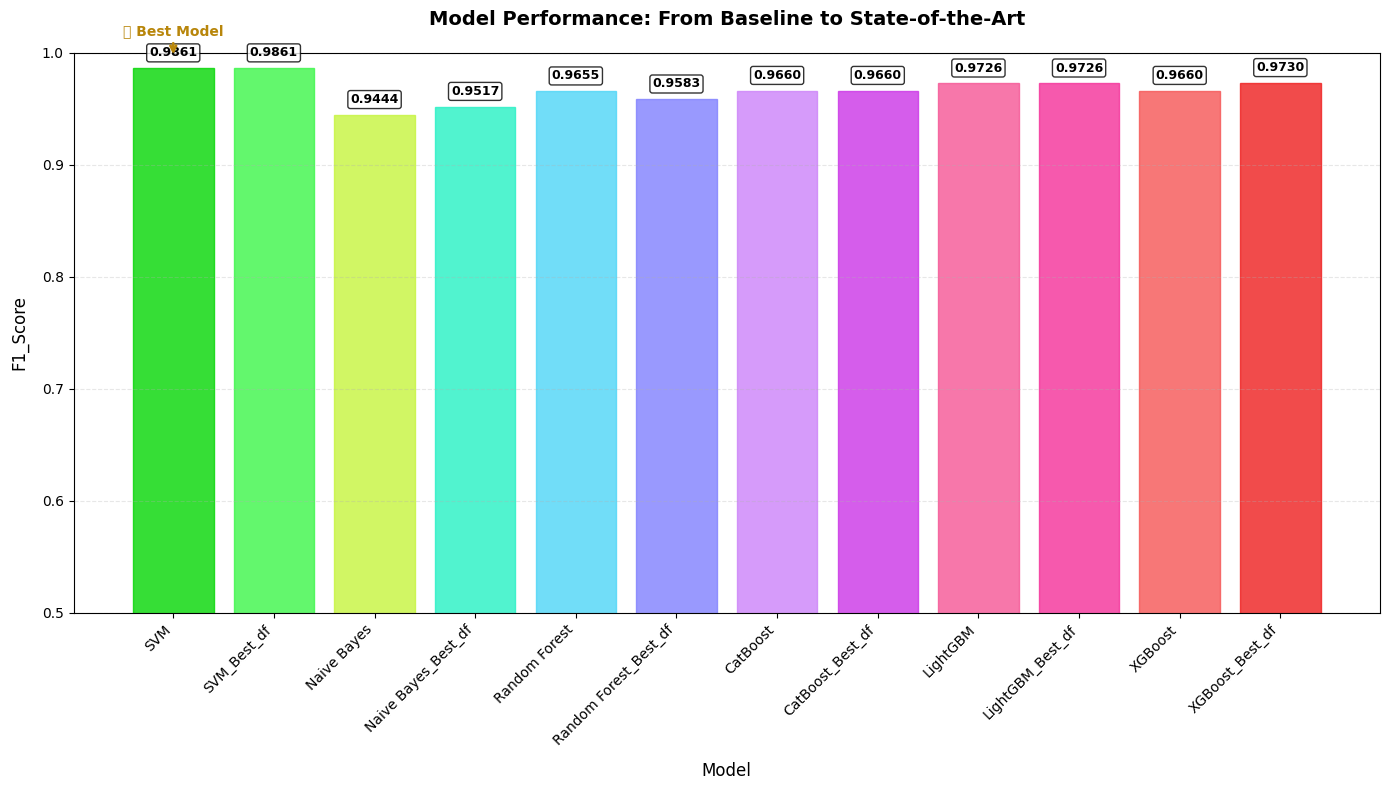

In [51]:
models = ['SVM', 'SVM_Best_df','Naive Bayes','Naive Bayes_Best_df',
          'Random Forest','Random Forest_Best_df','CatBoost', 'CatBoost_Best_df',
          'LightGBM','LightGBM_Best_df','XGBoost','XGBoost_Best_df']
f1_scores = [f1_svm, f1_best_svm, f1_nb, f1_best_nb, f1_rf, f1_best_rf, f1_catboost,
             f1_best_catboost, f1_lgbm, f1_best_lgbm, f1_xgb, f1_best_xgb]


plt.figure(figsize=(14, 8))
bars = plt.bar(models, f1_scores, color='steelblue', edgecolor='black', alpha=0.8)

# Rotate labels and adjust position
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Adjust bottom margin to make room for rotated labels
plt.subplots_adjust(bottom=0.25)

# Add labels
plt.xlabel('Model', fontsize=12, labelpad=10)
plt.ylabel('F1_Score', fontsize=12, labelpad=10)
plt.title('Model Performance: From Baseline to State-of-the-Art', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylim(0.5, 1)

# Add horizontal grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Color coding based on performance
colors = [ "#03d603","#3cf649", "#c6f43d", "#26f0c4", "#4dd5f7", 
          "#8080fe", "#cc82f9", "#cb34e6", "#f55595",
           "#f43099", "#f55555", "#ee1e1e"]
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Add value labels with background
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{score:.4f}', ha='center', va='bottom', fontsize=9, 
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', 
                                         facecolor='white', alpha=0.8))

# Add annotation for best model
best_idx = f1_scores.index(max(f1_scores))
plt.annotate('🏆 Best Model', 
             xy=(best_idx, max(f1_scores) + 0.01),
             xytext=(best_idx, max(f1_scores) + 0.03),
             ha='center',
             arrowprops=dict(arrowstyle='->', color='darkgoldenrod', lw=2),
             fontsize=10, fontweight='bold', color='darkgoldenrod')

plt.tight_layout()
plt.savefig('model_comparison_rotated.png', dpi=300, bbox_inches='tight')
plt.show()

### Compare Dataframes in Models:

In [52]:

def compare_dataframes(df, best_df, target_col= 'target', test_size=0.2, random_state=42):
    """
    Compare model performance between original and optimized dataframes
    """
    # Prepare original data
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Prepare optimized data
    X_best = best_df.drop(target_col, axis=1)
    y_best = best_df[target_col]

    # Prepare original data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
        )

    # Prepare optimized data
    X_best = best_df.drop('target', axis=1)
    y_best = best_df['target']
    X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
        X_best, y_best, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_best
        )
    
    # Define models to test
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=random_state),
        'LightGBM': LGBMClassifier(verbose=-1, random_state=random_state),
        'CatBoost': CatBoostClassifier(verbose=0, random_state=random_state),
        'SVM': SVC(random_state=random_state),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }
    
    # Store results
    results = []
    
    print("="*80)
    print("COMPARING MODEL PERFORMANCE: ORIGINAL vs OPTIMIZED DATA")
    print("="*80)
    # classification_report
    for name, model in models.items():
        # Train on original data
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc_orig = accuracy_score(y_test, y_pred)
        prec_orig = precision_score(y_test, y_pred, average='weighted')
        rec_orig = recall_score(y_test, y_pred, average='weighted')
        f1_orig = f1_score(y_test, y_pred, average='weighted')
        cm_orig = confusion_matrix(y_test, y_pred)


        # Train on optimized data
        model.fit(X_train_best, y_train_best)
        y_pred_best = model.predict(X_test_best)
        
        acc_best = accuracy_score(y_test_best, y_pred_best)
        prec_best = precision_score(y_test_best, y_pred_best, average='weighted')
        rec_best = recall_score(y_test_best, y_pred_best, average='weighted')
        f1_best = f1_score(y_test_best, y_pred_best, average='weighted')
        cm_best = confusion_matrix(y_test_best, y_pred_best)

                # Calculate CM difference (total misclassifications)
        cm_diff = cm_best.sum() - cm_orig.sum()  # Compare total predictions

        # Store results
        results.append({
            'Model': name,
            'Orig_Accuracy': acc_orig,
            'Best_Accuracy': acc_best,
            'Accuracy_Change': acc_best - acc_orig,
            'Orig_Precision': prec_orig,
            'Best_Precision': prec_best,
            'Orig_Recall': rec_orig,
            'Best_Recall': rec_best,
            'Orig_F1': f1_orig,
            'Best_F1': f1_best,
            'F1_Change': f1_best - f1_orig,
            'Orig_CM': cm_orig,
            'Best_CM': cm_best,
            'CM_Diff': cm_diff,
        })
        
        # Print individual results
        print(f"\n{'─'*60}")
        print(f"📊 {name}")
        print(f"{'─'*60}")
        print(f"  Accuracy:  {acc_orig:.4f} → {acc_best:.4f} ({'+'if acc_best>=acc_orig else ''}{acc_best-acc_orig:+.4f})")
        print(f"  Precision: {prec_orig:.4f} → {prec_best:.4f} ({'+'if prec_best>=prec_orig else ''}{prec_best-prec_orig:+.4f})")
        print(f"  Recall:    {rec_orig:.4f} → {rec_best:.4f} ({'+'if rec_best>=rec_orig else ''}{rec_best-rec_orig:+.4f})")
        print(f"  F1 Score:  {f1_orig:.4f} → {f1_best:.4f} ({'+'if f1_best>=f1_orig else ''}{f1_best-f1_orig:+.4f})")
        print(f"\n  Original Confusion Matrix:")
        print(f"  {cm_orig[0]} (TN, FP)")
        print(f"  {cm_orig[1]} (FN, TP)")
        print(f"\n  Optimized Confusion Matrix:")
        print(f"  {cm_best[0]} (TN, FP)")
        print(f"  {cm_best[1]} (FN, TP)")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, models

# Run comparison
results_df, models = compare_dataframes(df, best_df, target_col='target')

# Show summary
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
display_cols = ['Model', 'Orig_Accuracy', 'Best_Accuracy', 'Accuracy_Change', 
                'Orig_F1', 'Best_F1', 'F1_Change']
print(results_df[display_cols].to_string(index=False))

# Find best model
best_model_idx = results_df['Best_Accuracy'].idxmax()
print(f"\n🏆 Best Performing Model: {results_df.loc[best_model_idx, 'Model']}    Accuracy: {results_df.loc[best_model_idx, 'Best_Accuracy']:.4f}")

# Find most improved model
most_improved_idx = results_df['Accuracy_Change'].idxmax()
print(f"\n📈 Most Improved Model: {results_df.loc[most_improved_idx, 'Model']}   Improvement: {results_df.loc[most_improved_idx, 'Accuracy_Change']:+.4f}")


COMPARING MODEL PERFORMANCE: ORIGINAL vs OPTIMIZED DATA

────────────────────────────────────────────────────────────
📊 Logistic Regression
────────────────────────────────────────────────────────────
  Accuracy:  0.9649 → 0.9649 (++0.0000)
  Precision: 0.9649 → 0.9652 (++0.0003)
  Recall:    0.9649 → 0.9649 (++0.0000)
  F1 Score:  0.9649 → 0.9647 (-0.0002)

  Original Confusion Matrix:
  [40  2] (TN, FP)
  [ 2 70] (FN, TP)

  Optimized Confusion Matrix:
  [39  3] (TN, FP)
  [ 1 71] (FN, TP)

────────────────────────────────────────────────────────────
📊 Decision Tree
────────────────────────────────────────────────────────────
  Accuracy:  0.9123 → 0.9123 (++0.0000)
  Precision: 0.9161 → 0.9195 (++0.0034)
  Recall:    0.9123 → 0.9123 (++0.0000)
  F1 Score:  0.9130 → 0.9133 (++0.0003)

  Original Confusion Matrix:
  [39  3] (TN, FP)
  [ 7 65] (FN, TP)

  Optimized Confusion Matrix:
  [40  2] (TN, FP)
  [ 8 64] (FN, TP)

────────────────────────────────────────────────────────────
📊 Ran

In [53]:
# Tune models
def compare_dataframes(df, best_df, target_col= 'target', test_size=0.2, random_state=42):
    """
    Compare model performance between original and optimized dataframes
    """
    # Prepare original data
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Prepare optimized data
    X_best = best_df.drop(target_col, axis=1)
    y_best = best_df[target_col]

    # Prepare original data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
        )

    # Prepare optimized data
    X_best = best_df.drop('target', axis=1)
    y_best = best_df['target']
    X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
        X_best, y_best, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_best
        )
    
    # Define models to test
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, 
            solver='liblinear', 
            penalty='l2',
            l1_ratio=0.1,
            random_state=random_state),

        'Decision Tree': DecisionTreeClassifier(
            criterion='log_loss', #'entropy',
            max_depth=100,
            max_features= 0.9193546958301854, # 'log2',
            ccp_alpha=0.0,
            min_samples_leaf= 15,
            min_samples_split= 24,
            random_state=random_state),
            
        'Random Forest': RandomForestClassifier( 
            n_estimators=200, 
            criterion='entropy', 
            class_weight= 'balanced',
            max_depth=50,  
            max_features= 'sqrt', 
            min_samples_leaf= 5, 
            min_samples_split= 10, 
            ccp_alpha=0.1,
            random_state=random_state),
        'XGBoost': XGBClassifier(
            booster= 'gbtree', 
            learning_rate=0.08, # *
            n_estimators=500, #*
            subsample=0.8,
            min_child_weight=5, # *
            colsample_bytree=0.8,
            objective= 'binary:logistic',
            nthread=4,
            scale_pos_weight=1,
            gamma=0.005, # *
            reg_alpha=0.004, #*
            max_depth=3, #*
            random_state=random_state),
        'LightGBM': LGBMClassifier(
            n_estimators=500, 
            learning_rate=0.1,
            max_depth=7, 
            num_leaves=25, 
            feature_fraction=0.8, 
            bagging_fraction=0.3, 
            bagging_freq= 1, 
            min_data_in_leaf=50, 
            #boosting_type= 'gbdt', # 'dart'
            verbose=-1, 
            random_state=random_state),

        'CatBoost': CatBoostClassifier(
            iterations=400, 
            learning_rate=0.1, 
            max_depth=5, 
            l2_leaf_reg=4.5, 
            min_data_in_leaf= 5, 
            boosting_type='Ordered', 
            bootstrap_type='Bayesian', 
             verbose=0, 
            random_state=random_state),
            # probability=True, kernel='rbf',random_state=42,
    
        'SVM': SVC(
            probability=True,
            kernel='rbf', 
            #C=0.5, # No important parameters
            #class_weight=None, # 'balanced'
            #gamma=0.0001, 
            #coef0=0.05,
            random_state=random_state),

        'KNN': KNeighborsClassifier(
            n_neighbors=7, # *
            metric= 'manhattan', # *
            weights='uniform', # distance -> same
            algorithm='kd_tree', # {‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}
            leaf_size=1, # *
            p=1)
    }
    
    # Store results
    results = []
    
    print("="*80)
    print("COMPARING MODEL PERFORMANCE: ORIGINAL vs OPTIMIZED DATA")
    print("="*80)
    # classification_report
    for name, model in models.items():
        # Train on original data
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc_orig = accuracy_score(y_test, y_pred)
        prec_orig = precision_score(y_test, y_pred, average='weighted')
        rec_orig = recall_score(y_test, y_pred, average='weighted')
        f1_orig = f1_score(y_test, y_pred, average='weighted')
        cm_orig = confusion_matrix(y_test, y_pred)


        # Train on optimized data
        model.fit(X_train_best, y_train_best)
        y_pred_best = model.predict(X_test_best)
        
        acc_best = accuracy_score(y_test_best, y_pred_best)
        prec_best = precision_score(y_test_best, y_pred_best, average='weighted')
        rec_best = recall_score(y_test_best, y_pred_best, average='weighted')
        f1_best = f1_score(y_test_best, y_pred_best, average='weighted')
        cm_best = confusion_matrix(y_test_best, y_pred_best)

                # Calculate CM difference (total misclassifications)
        cm_diff = cm_best.sum() - cm_orig.sum()  # Compare total predictions

        # Store results
        results.append({
            'Model': name,
            'Orig_Accuracy': acc_orig,
            'Best_Accuracy': acc_best,
            'Accuracy_Change': acc_best - acc_orig,
            'Orig_Precision': prec_orig,
            'Best_Precision': prec_best,
            'Orig_Recall': rec_orig,
            'Best_Recall': rec_best,
            'Orig_F1': f1_orig,
            'Best_F1': f1_best,
            'F1_Change': f1_best - f1_orig,
            'Orig_CM': cm_orig,
            'Best_CM': cm_best,
            'CM_Diff': cm_diff,
        })
        
        # Print individual results
        print(f"\n{'─'*60}")
        print(f"📊 {name}")
        print(f"{'─'*60}")
        print(f"  Accuracy:  {acc_orig:.4f} → {acc_best:.4f} ({'+'if acc_best>=acc_orig else ''}{acc_best-acc_orig:+.4f})")
        print(f"  Precision: {prec_orig:.4f} → {prec_best:.4f} ({'+'if prec_best>=prec_orig else ''}{prec_best-prec_orig:+.4f})")
        print(f"  Recall:    {rec_orig:.4f} → {rec_best:.4f} ({'+'if rec_best>=rec_orig else ''}{rec_best-rec_orig:+.4f})")
        print(f"  F1 Score:  {f1_orig:.4f} → {f1_best:.4f} ({'+'if f1_best>=f1_orig else ''}{f1_best-f1_orig:+.4f})")
        print(f"\n  Original Confusion Matrix:")
        print(f"  {cm_orig[0]} (TN, FP)")
        print(f"  {cm_orig[1]} (FN, TP)")
        print(f"\n  Optimized Confusion Matrix:")
        print(f"  {cm_best[0]} (TN, FP)")
        print(f"  {cm_best[1]} (FN, TP)")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, models

# Run comparison
results_df, models = compare_dataframes(df, best_df, target_col='target')

# Show summary
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
display_cols = ['Model', 'Orig_Accuracy', 'Best_Accuracy', 'Accuracy_Change', 
                'Orig_F1', 'Best_F1', 'F1_Change']

print(results_df[display_cols].to_string(index=False))

# Find final model -> above 0.99
results_df['Max'] = results_df[['Orig_Accuracy', 'Best_Accuracy']].max(axis=1)
results_df['Fin_Sc'] = results_df.groupby('Model')['Max'].transform('max')
results_df = results_df.sort_values('Fin_Sc', ascending=False).reset_index(drop=True)
results_df['Fin_Sc']

best_model_idx = results_df['Fin_Sc'].idxmax()
print(f"\n🏆 Best Performing Model: {results_df.loc[best_model_idx, 'Model']}   Accuracy: {results_df.loc[best_model_idx, 'Fin_Sc']:.4f}")


# # Find most improved model
# most_improved_idx = results_df['Accuracy_Change'].idxmax()
# print(f"\n📈 Most Improved Model: {results_df.loc[most_improved_idx, 'Model']}")
# print(f"   Improvement: {results_df.loc[most_improved_idx, 'Accuracy_Change']:+.4f}")

COMPARING MODEL PERFORMANCE: ORIGINAL vs OPTIMIZED DATA

────────────────────────────────────────────────────────────
📊 Logistic Regression
────────────────────────────────────────────────────────────
  Accuracy:  0.9561 → 0.9474 (-0.0088)
  Precision: 0.9561 → 0.9474 (-0.0086)
  Recall:    0.9561 → 0.9474 (-0.0088)
  F1 Score:  0.9560 → 0.9471 (-0.0089)

  Original Confusion Matrix:
  [39  3] (TN, FP)
  [ 2 70] (FN, TP)

  Optimized Confusion Matrix:
  [38  4] (TN, FP)
  [ 2 70] (FN, TP)

────────────────────────────────────────────────────────────
📊 Decision Tree
────────────────────────────────────────────────────────────
  Accuracy:  0.9561 → 0.9561 (++0.0000)
  Precision: 0.9565 → 0.9565 (++0.0000)
  Recall:    0.9561 → 0.9561 (++0.0000)
  F1 Score:  0.9562 → 0.9562 (++0.0000)

  Original Confusion Matrix:
  [40  2] (TN, FP)
  [ 3 69] (FN, TP)

  Optimized Confusion Matrix:
  [40  2] (TN, FP)
  [ 3 69] (FN, TP)

────────────────────────────────────────────────────────────
📊 Random